# Science Image Reduction

This notebook calibrates the raw science exposure of **158P** using the
master bias and normalized R-band master flat generated previously.

The reduction workflow is:

1. Load the raw science exposure.
2. Apply independent overscan correction to both CCD amplifiers.
3. Trim the image to the 2048 × 2048 science region.
4. Subtract the master bias.
5. Identify unreliable detector pixels.
6. Divide by the normalized master flat.
7. Inspect and save the calibrated science image.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats

In [2]:
PROJECT_DIR = Path("..").resolve()

PRODUCTS_DIR = PROJECT_DIR / "products"
FIGURES_DIR = PROJECT_DIR / "Figures"

print(PROJECT_DIR)

C:\Users\rodri\NoirLab


In [3]:
science_candidates = sorted(PROJECT_DIR.glob("*.fits*"))

print("Science candidates:")

for file in science_candidates:
    print(file.name)

Science candidates:
c09i_180419_050252_ori.fits.fz


In [4]:
science_file = science_candidates[0]

print("Science file:")
print(science_file)

Science file:
C:\Users\rodri\NoirLab\c09i_180419_050252_ori.fits.fz


In [5]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""

    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i

    raise ValueError(f"No 2D image found in {filename}")

In [6]:
def overscan_correct_and_trim(data):
    """
    Perform row-by-row overscan correction for the two amplifiers
    and reconstruct the 2048 x 2048 detector image.
    """

    # Amplifier 1
    amp1 = data[:, 10:1034].astype(float)
    overscan1 = data[:, 1044:1084].astype(float)

    level1 = np.median(
        overscan1,
        axis=1,
        keepdims=True
    )

    amp1_corrected = amp1 - level1

    # Amplifier 2
    amp2 = data[:, 1134:2158].astype(float)
    overscan2 = data[:, 1084:1124].astype(float)

    level2 = np.median(
        overscan2,
        axis=1,
        keepdims=True
    )

    amp2_corrected = amp2 - level2

    return np.hstack([
        amp1_corrected,
        amp2_corrected
    ])

In [7]:
master_bias_path = PRODUCTS_DIR / "master_bias.fits"
master_flat_path = PRODUCTS_DIR / "master_flat_r.fits"

with fits.open(master_bias_path) as hdul:
    master_bias = hdul[0].data.astype(float)

with fits.open(master_flat_path) as hdul:
    master_flat = hdul[0].data.astype(float)

print("Master Bias:", master_bias.shape)
print("Master Flat:", master_flat.shape)

Master Bias: (2048, 2048)
Master Flat: (2048, 2048)


In [8]:
science_hdu = get_image_hdu(science_file)

with fits.open(science_file) as hdul:
    raw_science = hdul[science_hdu].data.astype(float)
    science_header = hdul[science_hdu].header.copy()

print("Raw science shape:", raw_science.shape)

print("OBJECT:", science_header.get("OBJECT"))
print("FILTER2:", science_header.get("FILTER2"))
print("EXPTIME:", science_header.get("EXPTIME"))
print("DETECTOR:", science_header.get("DETECTOR"))

Raw science shape: (2048, 2168)
OBJECT: 158P
FILTER2: r
EXPTIME: 60.0
DETECTOR: Tek2K_3


In [9]:
science_trimmed = overscan_correct_and_trim(
    raw_science
)

print("Raw shape:", raw_science.shape)
print("Trimmed shape:", science_trimmed.shape)

Raw shape: (2048, 2168)
Trimmed shape: (2048, 2048)


In [10]:
science_bias_corrected = (
    science_trimmed - master_bias
)

In [11]:
mean_sci, median_sci, std_sci = sigma_clipped_stats(
    science_bias_corrected,
    sigma=3,
    maxiters=5
)

print("Bias-corrected science:")
print(f"Mean   : {mean_sci:.3f} ADU")
print(f"Median : {median_sci:.3f} ADU")
print(f"Std    : {std_sci:.3f} ADU")

Bias-corrected science:
Mean   : 32.020 ADU
Median : 32.000 ADU
Std    : 6.764 ADU


In [12]:
bad_flat = (
    ~np.isfinite(master_flat) |
    (master_flat < 0.5) |
    (master_flat > 1.5)
)

In [13]:
bad_bias = (
    ~np.isfinite(master_bias) |
    (master_bias < -500) |
    (master_bias > 500)
)

In [14]:
bad_pixel_mask = bad_flat | bad_bias

print(
    "Bad pixels:",
    np.sum(bad_pixel_mask)
)

print(
    "Fraction:",
    100 * np.sum(bad_pixel_mask) /
    bad_pixel_mask.size,
    "%"
)

Bad pixels: 14759
Fraction: 0.3518819808959961 %


In [16]:
safe_flat = master_flat.copy()

safe_flat[bad_pixel_mask] = np.nan

In [17]:
science_calibrated = (
    science_bias_corrected /
    safe_flat
)

In [19]:
mean_cal, median_cal, std_cal = sigma_clipped_stats(
    science_calibrated,
    sigma=3,
    maxiters=5
)

print("=== Calibrated Science ===")
print(f"Mean   : {mean_cal:.3f} ADU")
print(f"Median : {median_cal:.3f} ADU")
print(f"Std    : {std_cal:.3f} ADU")

=== Calibrated Science ===
Mean   : 31.998 ADU
Median : 31.969 ADU
Std    : 6.725 ADU


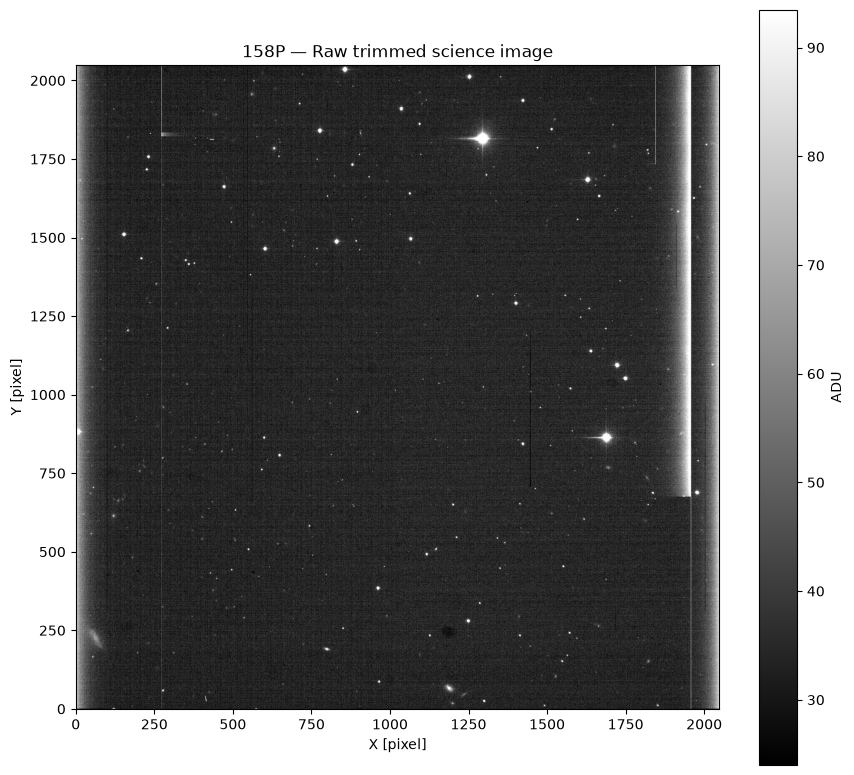

In [20]:
vmin_raw, vmax_raw = np.nanpercentile(
    science_trimmed,
    [5, 99.5]
)

plt.figure(figsize=(9, 8))

plt.imshow(
    science_trimmed,
    origin="lower",
    cmap="gray",
    vmin=vmin_raw,
    vmax=vmax_raw
)

plt.colorbar(label="ADU")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Raw trimmed science image")

plt.tight_layout()
plt.show()

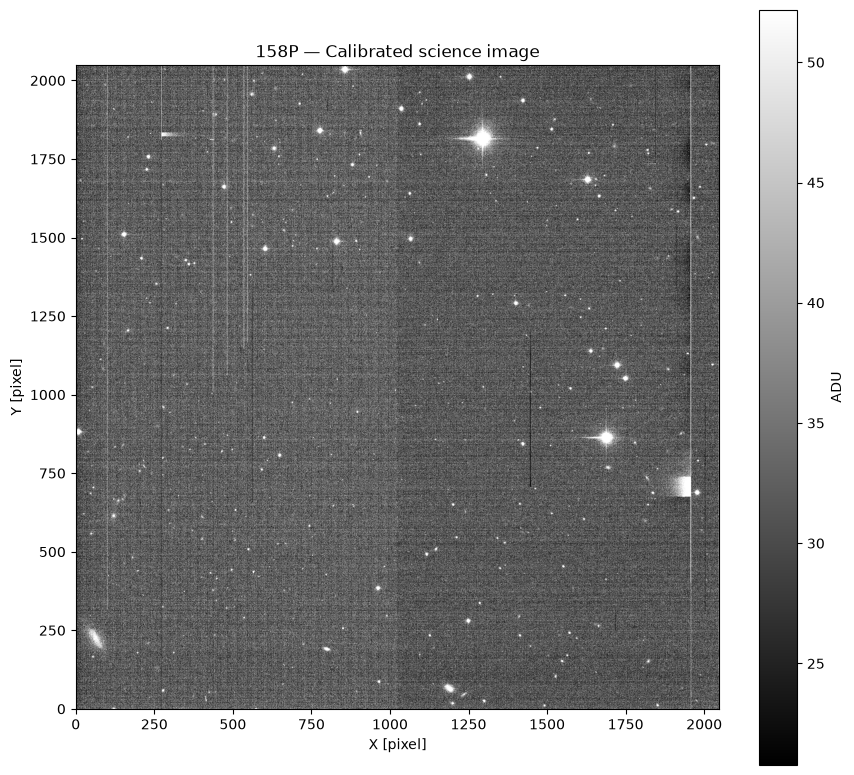

In [21]:
vmin_cal, vmax_cal = np.nanpercentile(
    science_calibrated,
    [5, 99.5]
)

plt.figure(figsize=(9, 8))

plt.imshow(
    science_calibrated,
    origin="lower",
    cmap="gray",
    vmin=vmin_cal,
    vmax=vmax_cal
)

plt.colorbar(label="ADU")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Calibrated science image")

plt.tight_layout()
plt.show()

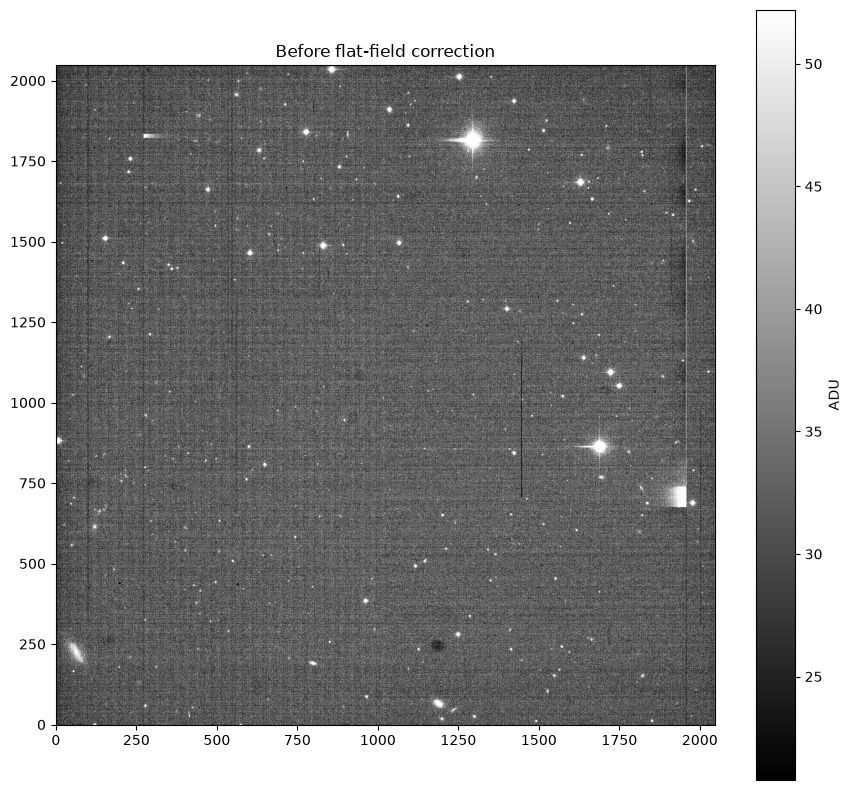

In [22]:
vmin, vmax = np.nanpercentile(
    science_calibrated,
    [5, 99.5]
)

plt.figure(figsize=(9, 8))

plt.imshow(
    science_bias_corrected,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")
plt.title("Before flat-field correction")

plt.tight_layout()
plt.show()

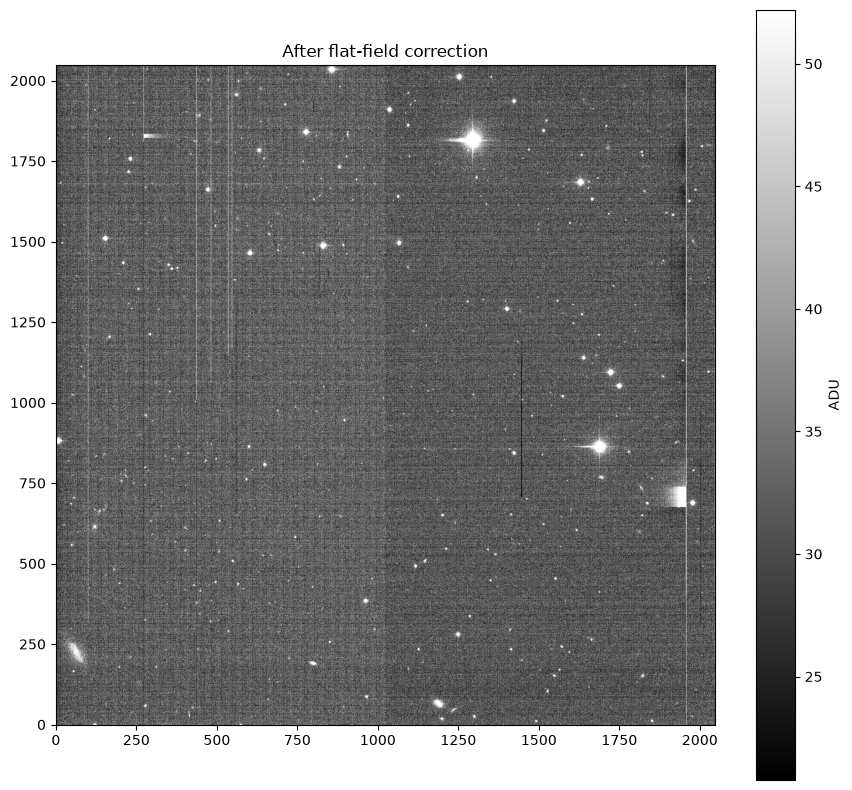

In [23]:
plt.figure(figsize=(9, 8))

plt.imshow(
    science_calibrated,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")
plt.title("After flat-field correction")

plt.tight_layout()
plt.show()

In [25]:
background_before = np.nanmedian(
    science_bias_corrected,
    axis=0
)

background_after = np.nanmedian(
    science_calibrated,
    axis=0
)

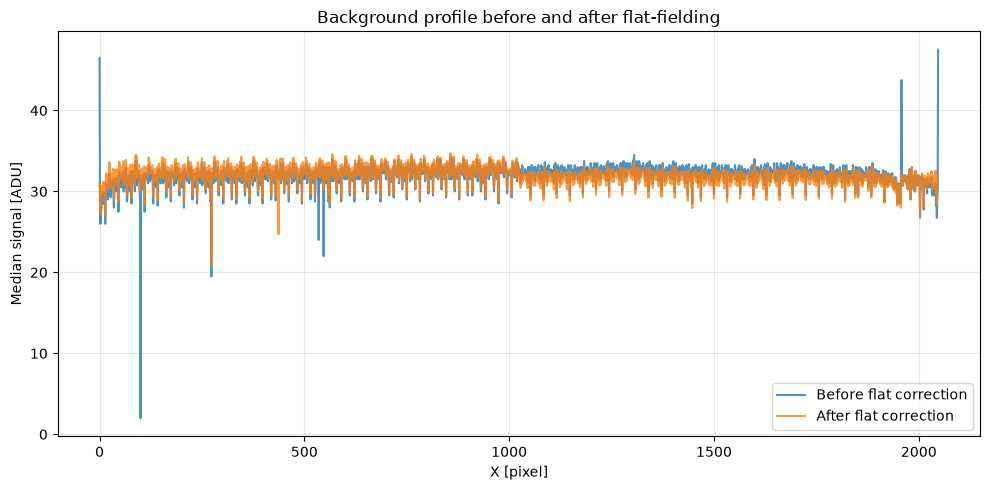

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    background_before,
    label="Before flat correction",
    alpha=0.8
)

plt.plot(
    background_after,
    label="After flat correction",
    alpha=0.8
)

plt.xlabel("X [pixel]")
plt.ylabel("Median signal [ADU]")

plt.title(
    "Background profile before and after flat-fielding"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
output_header = science_header.copy()

output_header["IMAGETYP"] = "CALIBRATED"
output_header["HISTORY"] = "Two-amplifier overscan correction applied"
output_header["HISTORY"] = "Image trimmed to 2048x2048 detector region"
output_header["HISTORY"] = "Master bias subtracted"
output_header["HISTORY"] = "R-band master flat applied"
output_header["HISTORY"] = "Bad pixels stored as NaN"

In [28]:
calibrated_path = (
    PRODUCTS_DIR /
    "158P_calibrated_r.fits"
)

fits.writeto(
    calibrated_path,
    science_calibrated.astype(np.float32),
    header=output_header,
    overwrite=True
)

print("Saved:")
print(calibrated_path)

Saved:
C:\Users\rodri\NoirLab\products\158P_calibrated_r.fits


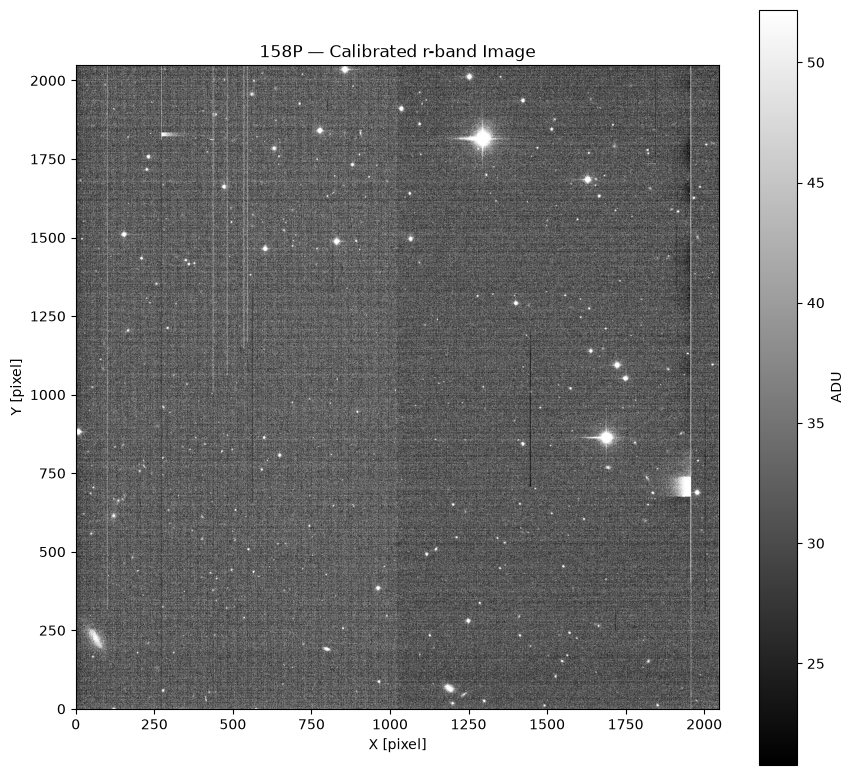

In [29]:
vmin, vmax = np.nanpercentile(
    science_calibrated,
    [5, 99.5]
)

plt.figure(figsize=(9, 8))

plt.imshow(
    science_calibrated,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Calibrated r-band Image")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "158P_calibrated_r.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [30]:
from astropy.stats import SigmaClip, sigma_clipped_stats, mad_std
from photutils.background import Background2D, MedianBackground

In [31]:
sigma_clip = SigmaClip(
    sigma=3.0,
    maxiters=10
)

bkg_estimator = MedianBackground()

In [32]:
background_before = Background2D(
    science_bias_corrected,
    box_size=(64, 64),
    filter_size=(3, 3),
    sigma_clip=sigma_clip,
    bkg_estimator=bkg_estimator,
    mask=bad_pixel_mask
)

In [33]:
background_after = Background2D(
    science_calibrated,
    box_size=(64, 64),
    filter_size=(3, 3),
    sigma_clip=sigma_clip,
    bkg_estimator=bkg_estimator,
    mask=bad_pixel_mask
)

In [34]:
bkg_before_map = background_before.background
bkg_after_map = background_after.background

In [35]:
_, med_before, std_before = sigma_clipped_stats(
    bkg_before_map,
    sigma=3
)

_, med_after, std_after = sigma_clipped_stats(
    bkg_after_map,
    sigma=3
)

mad_before = mad_std(
    bkg_before_map,
    ignore_nan=True
)

mad_after = mad_std(
    bkg_after_map,
    ignore_nan=True
)

print("=== Background uniformity ===")

print("\nBefore flat correction:")
print(f"Median : {med_before:.4f} ADU")
print(f"Std    : {std_before:.4f} ADU")
print(f"MAD std: {mad_before:.4f} ADU")

print("\nAfter flat correction:")
print(f"Median : {med_after:.4f} ADU")
print(f"Std    : {std_after:.4f} ADU")
print(f"MAD std: {mad_after:.4f} ADU")

=== Background uniformity ===

Before flat correction:
Median : 32.0482 ADU
Std    : 0.5496 ADU
MAD std: 0.6326 ADU

After flat correction:
Median : 31.9336 ADU
Std    : 0.5413 ADU
MAD std: 0.6578 ADU


In [36]:
all_background = np.concatenate([
    bkg_before_map.ravel(),
    bkg_after_map.ravel()
])

vmin, vmax = np.nanpercentile(
    all_background,
    [2, 98]
)

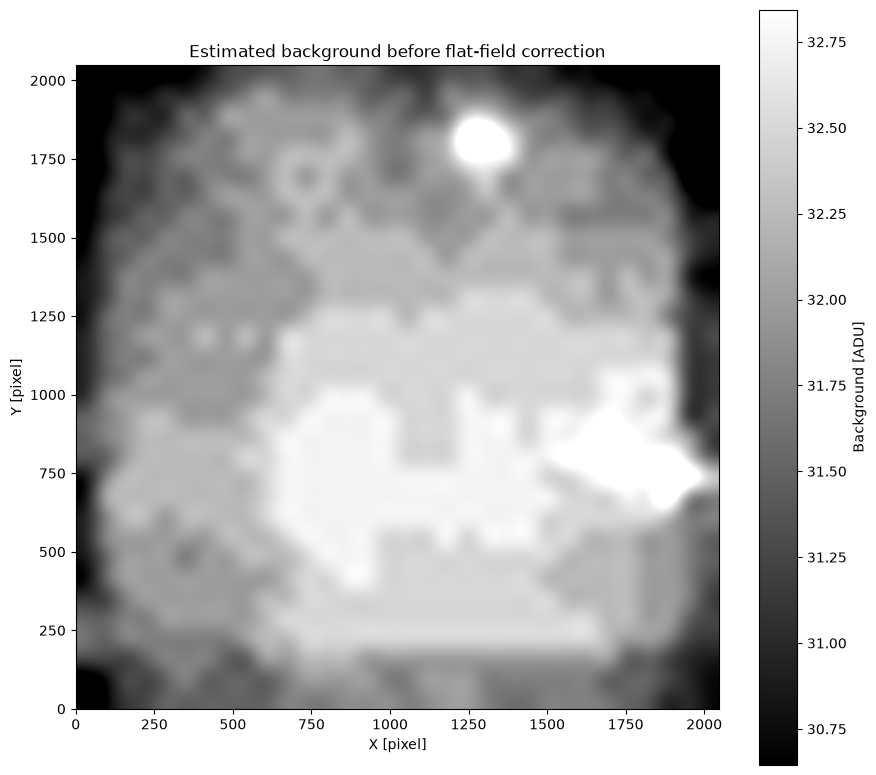

In [37]:
plt.figure(figsize=(9, 8))

plt.imshow(
    bkg_before_map,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Background [ADU]")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Estimated background before flat-field correction")

plt.tight_layout()
plt.show()

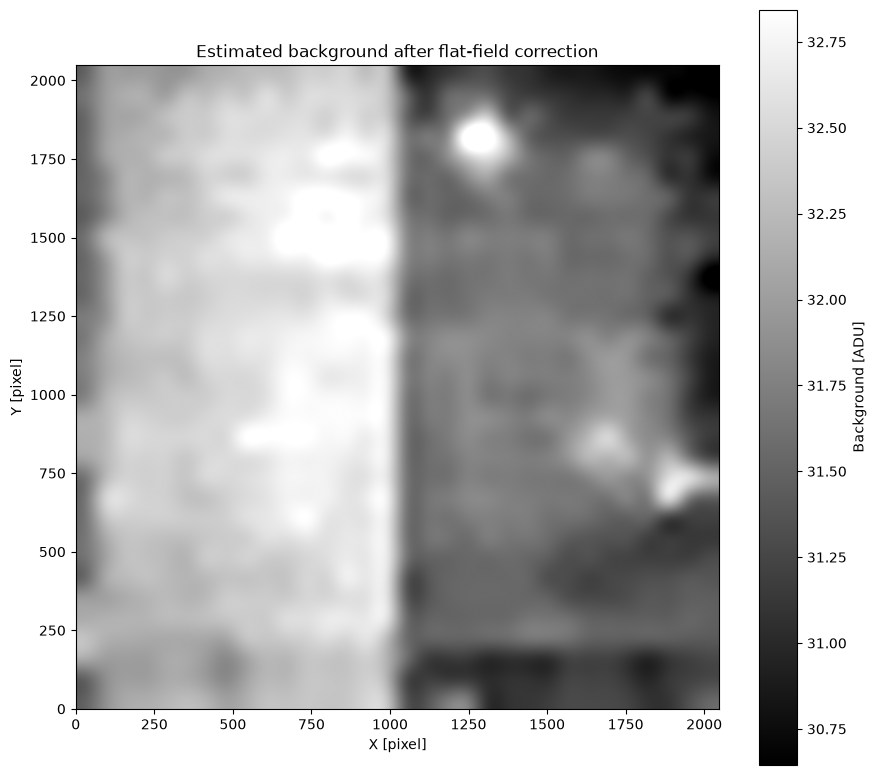

In [38]:
plt.figure(figsize=(9, 8))

plt.imshow(
    bkg_after_map,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Background [ADU]")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Estimated background after flat-field correction")

plt.tight_layout()
plt.show()

In [39]:
def binned_background_profile(image, bin_width=64):

    x = []
    profile = []

    nx = image.shape[1]

    for x0 in range(0, nx, bin_width):

        x1 = min(x0 + bin_width, nx)

        block = image[:, x0:x1]

        profile.append(
            np.nanmedian(block)
        )

        x.append(
            (x0 + x1) / 2
        )

    return np.array(x), np.array(profile)

In [40]:
x_before, profile_before = binned_background_profile(
    bkg_before_map,
    bin_width=64
)

x_after, profile_after = binned_background_profile(
    bkg_after_map,
    bin_width=64
)

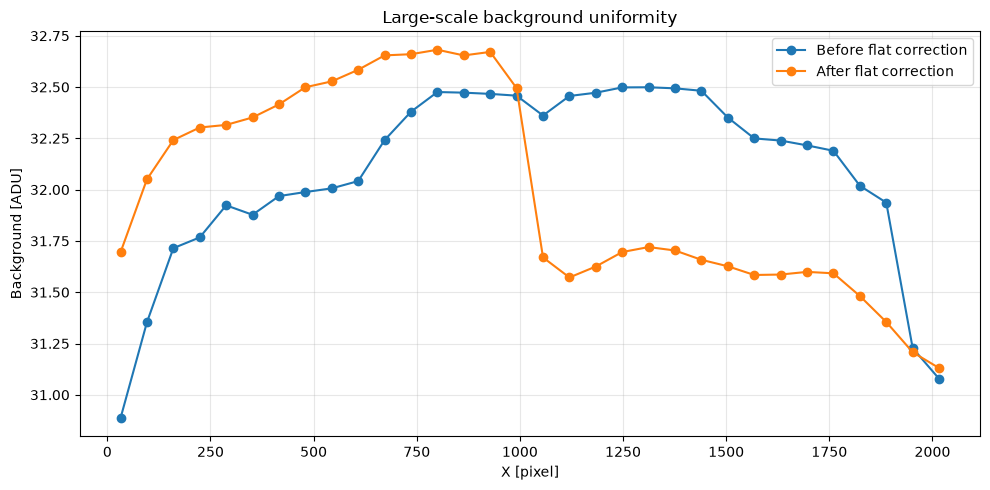

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    x_before,
    profile_before,
    marker="o",
    label="Before flat correction"
)

plt.plot(
    x_after,
    profile_after,
    marker="o",
    label="After flat correction"
)

plt.xlabel("X [pixel]")
plt.ylabel("Background [ADU]")

plt.title(
    "Large-scale background uniformity"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
flat_profile = np.nanmedian(
    np.where(
        bad_pixel_mask,
        np.nan,
        master_flat
    ),
    axis=0
)

science_profile = np.nanmedian(
    np.where(
        bad_pixel_mask,
        np.nan,
        science_bias_corrected
    ),
    axis=0
)

In [44]:
flat_profile_norm = (
    flat_profile /
    np.nanmedian(flat_profile)
)

science_profile_norm = (
    science_profile /
    np.nanmedian(science_profile)
)

In [45]:
valid = (
    np.isfinite(flat_profile_norm) &
    np.isfinite(science_profile_norm)
)

correlation = np.corrcoef(
    flat_profile_norm[valid],
    science_profile_norm[valid]
)[0, 1]

print(
    "Correlation between science background "
    f"and flat response: {correlation:.4f}"
)

Correlation between science background and flat response: 0.4090


In [46]:
from astropy.stats import sigma_clipped_stats

# Master Flat dividido por amplificadores
mf_amp1 = master_flat[:, :1024]
mf_amp2 = master_flat[:, 1024:]

_, med_mf1, std_mf1 = sigma_clipped_stats(
    mf_amp1, sigma=3, maxiters=5
)

_, med_mf2, std_mf2 = sigma_clipped_stats(
    mf_amp2, sigma=3, maxiters=5
)

print("=== Master Flat by amplifier ===")

print("\nAmplifier 1:")
print(f"Median = {med_mf1:.6f}")
print(f"Std    = {std_mf1:.6f}")

print("\nAmplifier 2:")
print(f"Median = {med_mf2:.6f}")
print(f"Std    = {std_mf2:.6f}")

print()
print(
    "Amp1 / Amp2 median ratio =",
    med_mf1 / med_mf2
)

=== Master Flat by amplifier ===

Amplifier 1:
Median = 0.986469
Std    = 0.013752

Amplifier 2:
Median = 1.021247
Std    = 0.014871

Amp1 / Amp2 median ratio = 0.9659457319214866


In [47]:
before_left = np.nanmedian(
    bkg_before_map[:, :1024]
)

before_right = np.nanmedian(
    bkg_before_map[:, 1024:]
)

after_left = np.nanmedian(
    bkg_after_map[:, :1024]
)

after_right = np.nanmedian(
    bkg_after_map[:, 1024:]
)

print("=== Background by amplifier ===")

print("\nBefore flat:")
print(f"Amp 1 = {before_left:.4f} ADU")
print(f"Amp 2 = {before_right:.4f} ADU")
print(
    f"Difference = {before_left-before_right:.4f} ADU"
)

print("\nAfter flat:")
print(f"Amp 1 = {after_left:.4f} ADU")
print(f"Amp 2 = {after_right:.4f} ADU")
print(
    f"Difference = {after_left-after_right:.4f} ADU"
)

=== Background by amplifier ===

Before flat:
Amp 1 = 31.9991 ADU
Amp 2 = 32.2302 ADU
Difference = -0.2310 ADU

After flat:
Amp 1 = 32.4370 ADU
Amp 2 = 31.5703 ADU
Difference = 0.8667 ADU


In [50]:
master_flat_amp_path = (
    PRODUCTS_DIR /
    "master_flat_r_ampnorm.fits"
)

with fits.open(master_flat_amp_path) as hdul:
    master_flat_amp = hdul[0].data.astype(float)

In [51]:
bad_flat_amp = (
    ~np.isfinite(master_flat_amp) |
    (master_flat_amp < 0.5) |
    (master_flat_amp > 1.5)
)

bad_pixel_mask_amp = (
    bad_flat_amp |
    bad_bias
)

In [52]:
safe_flat_amp = master_flat_amp.copy()

safe_flat_amp[
    bad_pixel_mask_amp
] = np.nan

In [53]:
science_calibrated_amp = (
    science_bias_corrected /
    safe_flat_amp
)

In [54]:
background_after_amp = Background2D(
    science_calibrated_amp,
    box_size=(64, 64),
    filter_size=(3, 3),
    sigma_clip=sigma_clip,
    bkg_estimator=bkg_estimator,
    mask=bad_pixel_mask_amp
)

bkg_after_amp_map = (
    background_after_amp.background
)

In [55]:
new_left = np.nanmedian(
    bkg_after_amp_map[:, :1024]
)

new_right = np.nanmedian(
    bkg_after_amp_map[:, 1024:]
)

print("=== New calibrated background ===")

print(f"Amp 1 = {new_left:.4f} ADU")
print(f"Amp 2 = {new_right:.4f} ADU")

print(
    f"Difference = "
    f"{new_left-new_right:.4f} ADU"
)

=== New calibrated background ===
Amp 1 = 32.0073 ADU
Amp 2 = 32.2349 ADU
Difference = -0.2277 ADU


In [56]:
_, med_new_bkg, std_new_bkg = sigma_clipped_stats(
    bkg_after_amp_map,
    sigma=3
)

mad_new_bkg = mad_std(
    bkg_after_amp_map,
    ignore_nan=True
)

print("=== Background comparison ===")

print("\nBefore flat:")
print("Std     = 0.5496")
print("MAD std = 0.6326")

print("\nOld global flat:")
print("Std     = 0.5413")
print("MAD std = 0.6578")

print("\nNew amplifier-normalized flat:")
print(f"Std     = {std_new_bkg:.4f}")
print(f"MAD std = {mad_new_bkg:.4f}")

=== Background comparison ===

Before flat:
Std     = 0.5496
MAD std = 0.6326

Old global flat:
Std     = 0.5413
MAD std = 0.6578

New amplifier-normalized flat:
Std     = 0.2927
MAD std = 0.3119


In [57]:
x_before, profile_before = binned_background_profile(
    bkg_before_map,
    bin_width=64
)

x_new, profile_new = binned_background_profile(
    bkg_after_amp_map,
    bin_width=64
)

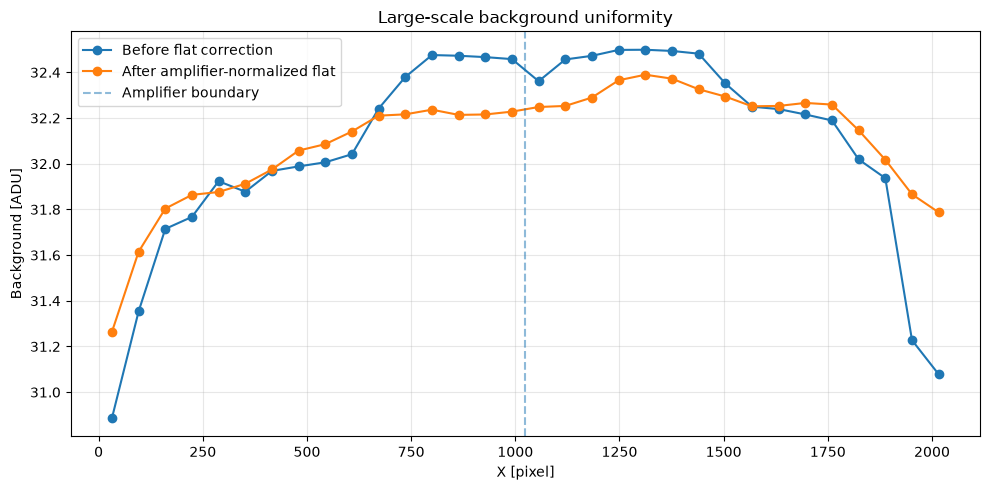

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(
    x_before,
    profile_before,
    marker="o",
    label="Before flat correction"
)

plt.plot(
    x_new,
    profile_new,
    marker="o",
    label="After amplifier-normalized flat"
)

plt.axvline(
    1024,
    linestyle="--",
    alpha=0.5,
    label="Amplifier boundary"
)

plt.xlabel("X [pixel]")
plt.ylabel("Background [ADU]")

plt.title(
    "Large-scale background uniformity"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
science_calibrated = science_calibrated_amp

In [60]:
bad_pixel_mask = bad_pixel_mask_amp

In [62]:
mean_final, median_final, std_final = sigma_clipped_stats(
    science_calibrated,
    sigma=3,
    maxiters=5
)

print("=== Final calibrated science image ===")
print(f"Mean   : {mean_final:.3f} ADU")
print(f"Median : {median_final:.3f} ADU")
print(f"Std    : {std_final:.3f} ADU")

=== Final calibrated science image ===
Mean   : 32.114 ADU
Median : 32.096 ADU
Std    : 6.732 ADU


In [63]:
output_header = science_header.copy()

output_header["IMAGETYP"] = "CALIBRATED"
output_header["HISTORY"] = "Two-amplifier overscan correction applied"
output_header["HISTORY"] = "Image trimmed to 2048x2048 detector region"
output_header["HISTORY"] = "Master bias subtracted"
output_header["HISTORY"] = "R-band master flat applied"
output_header["HISTORY"] = "Flat normalized independently by CCD amplifier"
output_header["HISTORY"] = "Bad detector pixels stored as NaN"

final_path = PRODUCTS_DIR / "158P_calibrated_r.fits"

fits.writeto(
    final_path,
    science_calibrated.astype(np.float32),
    header=output_header,
    overwrite=True
)

print("Saved:")
print(final_path)

Saved:
C:\Users\rodri\NoirLab\products\158P_calibrated_r.fits


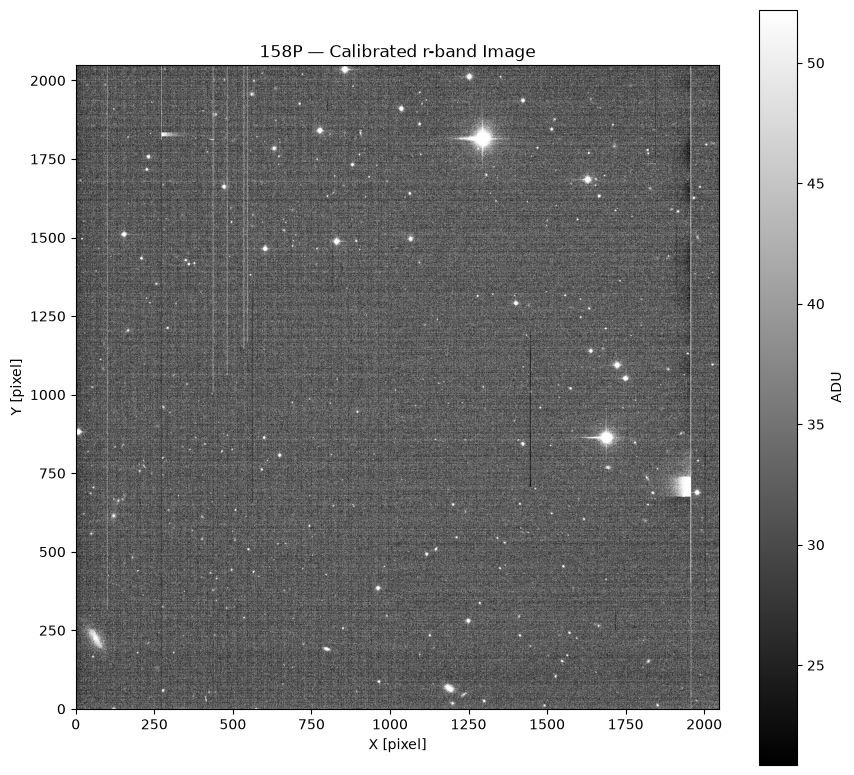

In [64]:
vmin, vmax = np.nanpercentile(
    science_calibrated,
    [5, 99.5]
)

plt.figure(figsize=(9, 8))

plt.imshow(
    science_calibrated,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Calibrated r-band Image")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "158P_calibrated_r.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

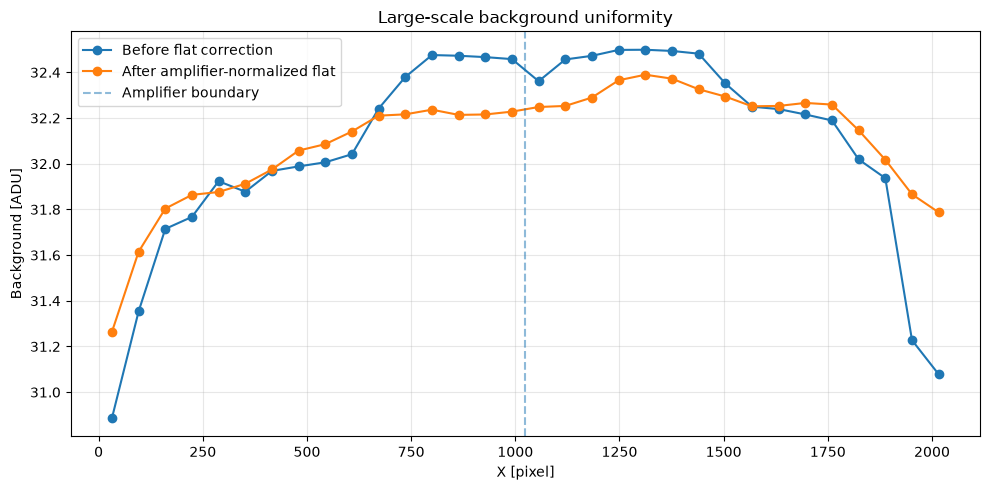

In [65]:
plt.figure(figsize=(10, 5))

plt.plot(
    x_before,
    profile_before,
    marker="o",
    label="Before flat correction"
)

plt.plot(
    x_new,
    profile_new,
    marker="o",
    label="After amplifier-normalized flat"
)

plt.axvline(
    1024,
    linestyle="--",
    alpha=0.5,
    label="Amplifier boundary"
)

plt.xlabel("X [pixel]")
plt.ylabel("Background [ADU]")
plt.title("Large-scale background uniformity")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "background_uniformity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Amplifier normalization

An initial master flat was produced by normalizing each complete flat exposure
by its global median. However, this produced a systematic discontinuity between
the two CCD amplifier regions.

The median responses of the initial master flat were approximately 0.986 and
1.021 for amplifiers 1 and 2, respectively. Applying this flat increased the
difference in the estimated sky background between the two detector halves.

The reduction was therefore revised by normalizing each amplifier independently
before combining the five dome-flat exposures.

The final master flat has amplifier median responses of approximately 1.00006
and 1.00014. After applying this corrected flat, the large-scale background
dispersion decreased from approximately 0.55 ADU to 0.29 ADU.

This illustrates the importance of accounting for the independent readout
characteristics of multi-amplifier CCD detectors.